In [24]:
import sklearn
print(sklearn.__version__)

1.7.2


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [26]:
data = load_breast_cancer(as_frame=True)
df = data.frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [27]:
df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [28]:
print('Rows and Columns of the Dataset : ',df.shape)

Rows and Columns of the Dataset :  (569, 31)


In [29]:
# Checking of Missing values
print('Missing value of the Dataset : \n',df.isnull().sum())

Missing value of the Dataset : 
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [30]:
# Check duplicates
df_dup = df.duplicated().sum()
print(f'Number of duplicate value is {df_dup}')

Number of duplicate value is 0


In [31]:
# Check outliers
Q1 = df['mean radius'].quantile(0.25)
Q3 = df['mean radius'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1- 1.5 *IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['mean radius'] < lower)|(df['mean radius'] > upper)]
print(f'Number of outliers in mean radius : {outliers.shape[0]}')

Number of outliers in mean radius : 14


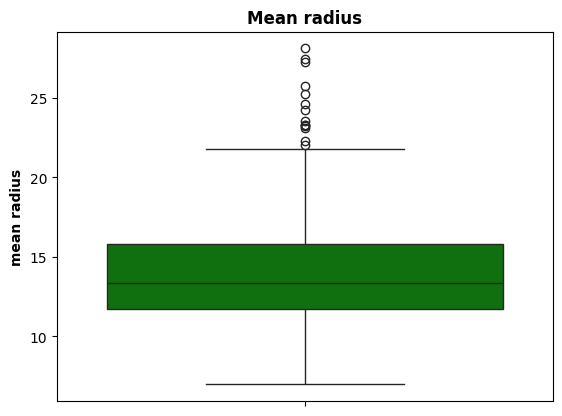

In [32]:
sns.boxplot(data=df['mean radius'], color='green')
plt.ylabel('mean radius',fontweight='bold')
plt.title('Mean radius',fontweight='bold')
plt.show()

In [33]:
# Remove outliers in mean radius only
df_clean = df[(df['mean radius'] >= lower) & (df['mean radius'] <= upper)]
print(f'Number of shape after removig the outliers : {df_clean.shape}')

Number of shape after removig the outliers : (555, 31)


In [34]:
x = df.drop('target',axis=1)
y = df['target']
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [35]:
print(x.shape)

(569, 30)


In [36]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [39]:
# Evaluate the Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_predict = model.predict(x_test)
print('Accuracy : ',accuracy_score(y_test, y_predict))
print('\n')
print('Confusion matrix : \n',confusion_matrix(y_test,y_predict))
print('\n')
print('Classification report : ',classification_report(y_test,y_predict))

Accuracy :  0.956140350877193


Confusion matrix : 
 [[39  4]
 [ 1 70]]


Classification report :                precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



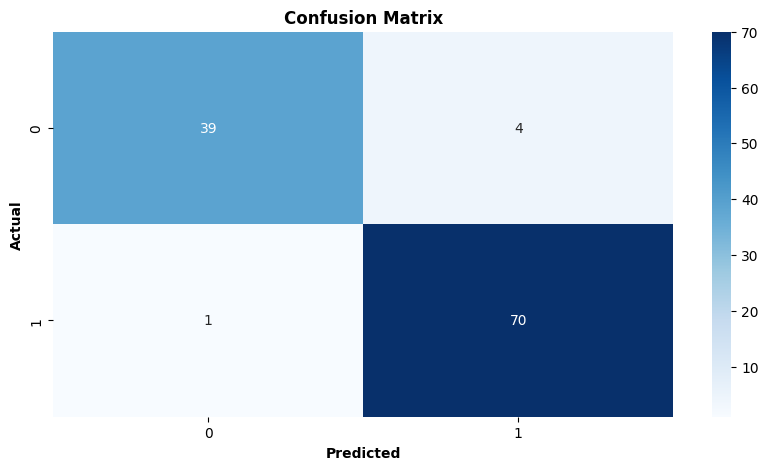

In [40]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(10,5))
sns.heatmap(data=cm, xticklabels=['0','1'], yticklabels=['0','1'], fmt='d', cmap='Blues',annot=True)
plt.xlabel('Predicted',fontweight='bold')
plt.ylabel('Actual',fontweight='bold')
plt.title('Confusion Matrix',fontweight='bold')
plt.show()

In [45]:
predictions = model.predict(x_test)
for i, pred in enumerate(predictions):
    print(f'Row {i}, Prediction : ','Benign'if pred == 1 else 'Malignant')

Row 0, Prediction :  Benign
Row 1, Prediction :  Malignant
Row 2, Prediction :  Malignant
Row 3, Prediction :  Benign
Row 4, Prediction :  Benign
Row 5, Prediction :  Malignant
Row 6, Prediction :  Malignant
Row 7, Prediction :  Malignant
Row 8, Prediction :  Benign
Row 9, Prediction :  Benign
Row 10, Prediction :  Benign
Row 11, Prediction :  Malignant
Row 12, Prediction :  Benign
Row 13, Prediction :  Malignant
Row 14, Prediction :  Benign
Row 15, Prediction :  Malignant
Row 16, Prediction :  Benign
Row 17, Prediction :  Benign
Row 18, Prediction :  Benign
Row 19, Prediction :  Malignant
Row 20, Prediction :  Benign
Row 21, Prediction :  Benign
Row 22, Prediction :  Malignant
Row 23, Prediction :  Benign
Row 24, Prediction :  Benign
Row 25, Prediction :  Benign
Row 26, Prediction :  Benign
Row 27, Prediction :  Benign
Row 28, Prediction :  Benign
Row 29, Prediction :  Malignant
Row 30, Prediction :  Benign
Row 31, Prediction :  Benign
Row 32, Prediction :  Benign
Row 33, Prediction :

In [48]:
row = x_test.iloc[5].values
prediction = model.predict([row])
print(f'Row {row} prediction : ','Benign' if prediction == 1 else 'Malignant')

Row [2.060e+01 2.933e+01 1.401e+02 1.265e+03 1.178e-01 2.770e-01 3.514e-01
 1.520e-01 2.397e-01 7.016e-02 7.260e-01 1.595e+00 5.772e+00 8.622e+01
 6.522e-03 6.158e-02 7.117e-02 1.664e-02 2.324e-02 6.185e-03 2.574e+01
 3.942e+01 1.846e+02 1.821e+03 1.650e-01 8.681e-01 9.387e-01 2.650e-01
 4.087e-01 1.240e-01] prediction :  Malignant


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
